# Residual Learning, Receptive Field, and UNet

This notebook develops the next steps beyond a plain CNN. We first discuss residual learning and why learning the artifact can be easier than learning the clean image directly. We then introduce the receptive field as a key design concept and conclude with the UNet architecture, which is often the strongest default choice for end-to-end image reconstruction.


### Residual CNN

Any CNN for image processing works by identifying **patterns** in the input image, which have been previously learned during training, and by reconstructing each pattern in the same way it was learned. For this reason, if, for example, we train a model to deblur images of cats, there is no guarantee that the same model will be able to deblur images of dogs: the different patterns present in dog images make accurate reconstruction much harder.

Consequently, a large line of research in CNN-based image processing tries to teach models to identify patterns that are typical of the **task** one wants to solve, rather than patterns that are specific to the training data. To this end, we can observe that while the patterns in the image are usually dataset-specific, the **artifact** (i.e. the difference between the corrupted image and the true image) tends to exhibit task-related patterns.

For example, consider the following problem, where two images coming from two completely different datasets are corrupted by Gaussian blur and noise. By looking at both the true image and the corrupted image, it is clear that the **content** of the two examples is very different.
On the other hand, when we look at the **residual**, i.e. the value $|x_{true} - y^\delta|$, the patterns in the two images look similar.

This observation justifies that **learning the residual is usually easier (and generalizes better) than learning the actual image**.


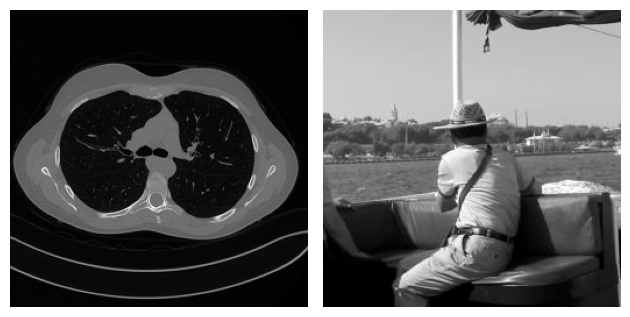

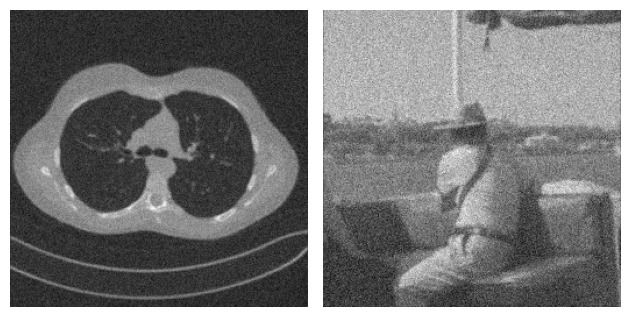

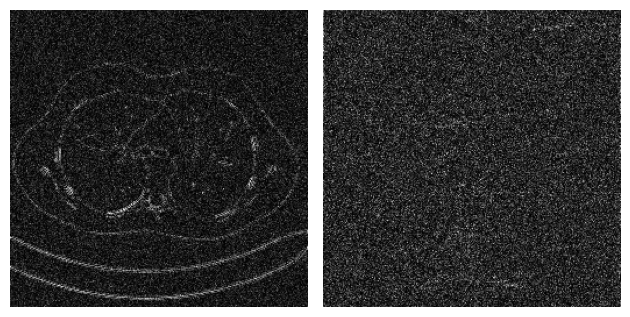

In [13]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "course_utils.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from course_utils import gray
import numpy as np
import torch

import torch
import matplotlib.pyplot as plt
from IPPy import operators
import torch.nn.functional as F

# Load images
x_mayo = torch.tensor(np.array(gray("Mayo.png"))).unsqueeze(0).unsqueeze(1)
x_mayo = F.interpolate(x_mayo.float(), size=(256, 256), mode="bilinear", align_corners=False)
x_mayo = (x_mayo - x_mayo.min()) / (x_mayo.max() - x_mayo.min())

x_gopro = torch.tensor(np.array(gray("GoPro.jpg"))).unsqueeze(0).unsqueeze(1)
x_gopro = F.interpolate(x_gopro.float(), size=(256, 256), mode="bilinear", align_corners=False)
x_gopro = (x_gopro - x_gopro.min()) / (x_gopro.max() - x_gopro.min())

# Visualize the images
plt.subplot(1, 2, 1)
plt.imshow(x_mayo.squeeze(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(x_gopro.squeeze(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# Corrupt and add noise
K = operators.Blurring(img_shape=(256, 256), kernel_type="gaussian", kernel_size=3, kernel_variance=1)

y_mayo = K(x_mayo)
y_mayo_delta = y_mayo + utilities.gaussian_noise(y_mayo, noise_level=0.2)

y_gopro = K(x_gopro)
y_gopro_delta = y_gopro + utilities.gaussian_noise(y_gopro, noise_level=0.2)

# Visualize the (corrupted) images
plt.subplot(1, 2, 1)
plt.imshow(y_mayo_delta.squeeze(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(y_gopro_delta.squeeze(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# Visualize the residual
plt.subplot(1, 2, 1)
plt.imshow(torch.abs(y_mayo_delta - x_mayo).squeeze(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(torch.abs(y_gopro_delta - x_gopro).squeeze(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


With this idea in mind, some authors developed a variant of the simple CNN architecture discussed above, in which the network is trained to learn **not** the reconstructed image itself, but rather the **residual**, which is then converted into the actual image by simply adding the corrupted image $y^\delta$ back to the output of the model. The operation of summing the input back into the output with the aim of learning the residual is usually called a **residual connection** or **skip connection**. These architectures are called **Residual Convolutional Neural Networks (ResCNNs)**.

What follows is a PyTorch implementation of a ResCNN architecture with the same basic structure as the CNN discussed previously. Note that we employ Tanh as the final activation function for this task, as already discussed in the previous section.


In [14]:
import torch
from torch import nn

class ResCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()

        # Define (convolution) layers -> NOTE: padding="same" means "padded convolution"
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding="same")

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        out = self.tanh(self.conv3(h))
        return out + x

Training a residual model follows exactly the same logic as for the plain CNN, but now the network learns a correction to be added back to the corrupted input. The code below trains a `ResCNN` for 50 epochs on the Mayo motion-blur task, saves the learned parameters in `../weights/ResCNN.pth`, reloads them, and visualizes one reconstruction together with the loss history.


Shape of x_true: torch.Size([1, 1, 256, 256]). Range of x_true: (tensor(0.), tensor(0.9113))
SSIM: 0.9394


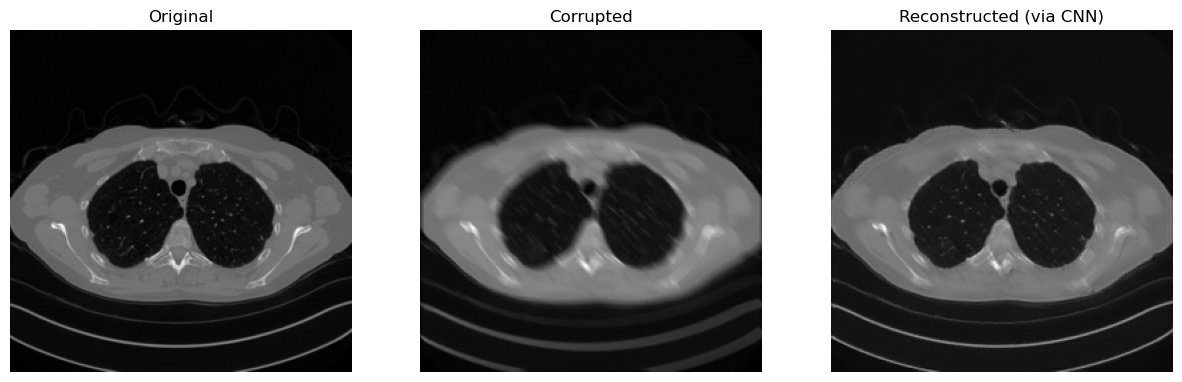

In [15]:
import glob
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

here = Path.cwd().resolve()
for base in (here, *here.parents):
    if (base / 'weights').exists() and (base / 'Mayo').exists():
        book_root = base
        break
else:
    raise FileNotFoundError('Could not locate the course root containing Mayo and weights.')

for base in (here, *here.parents):
    if (base / 'IPPy').exists():
        ippy_root = base / 'IPPy'
        break
else:
    raise FileNotFoundError('Could not locate the local IPPy package.')

operators_spec = importlib.util.spec_from_file_location('course_ippy_operators', ippy_root / 'operators.py')
operators = importlib.util.module_from_spec(operators_spec)
operators_spec.loader.exec_module(operators)

weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)

def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    try:
        if torch.backends.mps.is_available():
            return 'mps'
    except AttributeError:
        pass
    return 'cpu'

def gaussian_noise(y, noise_level):
    e = torch.randn_like(y, device=y.device)
    return e / torch.norm(e) * torch.norm(y) * noise_level

class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape):
        super().__init__()
        self.data_path = data_path
        self.data_shape = data_shape
        self.fname_list = glob.glob(f'{data_path}/*/*.png')

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        img_path = self.fname_list[idx]
        x = Image.open(img_path).convert('L')
        x = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(self.data_shape),
        ])(x)
        return x

device = get_device()
train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=256)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=256)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

K = operators.Blurring(
    img_shape=(256, 256),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

torch.manual_seed(0)
model = ResCNN(in_ch=1, out_ch=1, n_filters=32, kernel_size=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 50
noise_level = 0.01
history = []
weights_path = weights_dir / 'ResCNN.pth'

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)

    for step, x_batch in enumerate(progress_bar, start=1):
        x_batch = x_batch.to(device)

        with torch.no_grad():
            y_batch = K(x_batch)
            y_batch = y_batch + gaussian_noise(y_batch, noise_level=noise_level)

        prediction = model(y_batch)
        loss = loss_fn(prediction, x_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

    history.append(epoch_loss / len(train_loader))
    print(f'Epoch {epoch + 1}: training loss = {history[-1]:.6f}')

torch.save(model.state_dict(), weights_path)
print(f'Saved ResCNN weights to: {weights_path}')

reloaded_model = ResCNN(in_ch=1, out_ch=1, n_filters=32, kernel_size=3)
reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
reloaded_model = reloaded_model.to(device)
reloaded_model.eval()

with torch.no_grad():
    x_true = next(iter(test_loader))[0:1].to(device)
    y_delta = K(x_true)
    y_delta = y_delta + gaussian_noise(y_delta, noise_level=noise_level)
    x_rec = reloaded_model(y_delta)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_rec.cpu().squeeze(), cmap='gray')
plt.title('Reloaded ResCNN')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.plot(history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Beyond CNN: the Receptive field

Modern neural-network architectures for image-processing tasks rarely use the simple CNN model described above. One reason is the concept of **Receptive Field (RF)**. To understand it, let us consider a model with $L$ convolutional layers, each with kernel size $\kappa_l = 3$, as depicted in the following figure. It is evident that each pixel in the feature map of the second layer is influenced only by a $3 \times 3$ portion of the first layer, that is, the input of the network. Similarly, each pixel in the feature map of the third layer is influenced by a $3 \times 3$ portion of the previous layer, and consequently by a $5 \times 5$ portion of the input image. The number of input-image pixels that affect the value of each pixel in the $l$-th feature map is what we call the receptive field of the $l$-th layer. By continuing this reasoning through the network up to the output, we can compute the receptive field of the whole network, which represents the number of input-image pixels that influence the network's output. This quantity is crucial because, when reconstructing corrupted data containing artifacts, understanding the RF helps ensure that the model captures and addresses those artifacts accurately. In particular, when the artifacts are local, a small receptive field is enough to give the model the ability to distinguish between the artifact and the image features, while when the artifacts are global, a large RF is required to produce an accurate reconstruction.

```{image} /imgs/receptive_field.png
:width: 800px
:align: center
```

Since we are interested in comparing neural network architectures in terms of their receptive field, we need to derive a formula to compute it for any given network. For each layer $l$, let $\kappa_l$ and $s_l$ be its kernel size and stride, respectively. Moreover, let $r_l$ be the receptive field, where the receptive field of the input layer is $r_0 = 1$ by definition. The value of $r_l$ can be computed with the recursive formula:

$$
    r_l = r_{l-1} + A_l,
$$

where $A_l$ is the non-overlapping area between subsequent filter applications. Note that $A_l$ can be computed simply as

$$
    A_l = (k_l - 1) \prod_{i=1}^l s_i,
$$

which implies that the receptive field at each $l$-th layer is:

$$
\begin{aligned}
    &r_0 = 1 \\
    &r_l = r_{l-1} + (k_l - 1) \prod_{i=1}^l s_i.
\end{aligned}
$$

This equation shows that the receptive field scales linearly with the depth of the network if the kernel size is fixed, while it is exponentially related to the stride. For this reason, using strided convolutional layers exponentially enlarges the receptive field of the model.


## UNet

Combining all the information discussed above, we are now ready to introduce arguably the most important neural-network model ever developed for image reconstruction: **UNet**. The UNet is a multi-scale variant of the Convolutional Neural Network architecture, and it is able to detect and correct both global and local artifacts effectively. The UNet architecture, depicted in the figure below, is a **fully convolutional neural network** with a **symmetric encoder-decoder structure** and **strided convolutions** used to enlarge its receptive field. The strides in the encoder layers naturally divide the network into distinct resolution levels, which we denote by $g$, with $g = 0, \dots, \mathcal{G}$, where $\mathcal{G}+1$ is the total number of levels in the network. At each level, a fixed number $n_g$ of blocks $B_1, \dots, B_{n_g}$ is applied. Specifically, each block is defined as a convolutional layer with $c_g$ channels, constant along the level, followed by a batch-normalization layer and then by a ReLU activation function. Given a baseline number of convolutional channels $c_0$ (corresponding to the number of channels in the first level), we compute the number of channels in the following levels through the recursive formula $c_{g+1} = 2c_g$, $g = 0, \dots, L-1$. In the experiments, we fixed $\mathcal{G}=4$, $n_0 = \dots = n_3 = 3$, and $c_0 = 64$.
As already mentioned, the decoder is symmetric to the encoder, with upsampling convolutional layers instead of strided convolutions. Moreover, to preserve high-frequency information, skip connections are added between the last layer at each level of the encoder and the first layer at the corresponding level of the decoder. To reduce the number of parameters with respect to the original architecture, it is common to implement these skip connections as additions rather than concatenations. A residual connection is also added between the input layer and the output layer, as discussed previously. The output of the resulting model can be written as:

$$
    F_\Theta(y^\delta) = y^\delta + f_\Theta(y^\delta),
$$

which implies that the network has to learn the residual mapping between the input and the expected output. For this reason, this model is often referred to in the literature as a **Residual UNet (ResUNet)**. The importance of the residual connection has been highlighted in theoretical work by Han et al., where the authors proved that the residual manifold containing the artifacts is easier to learn than the true image manifold. As in many residual neural-network models, we usually employ a Tanh activation function in the last layer.

```{image} /imgs/ResUNet.png
:width: 800px
:align: center
```

The UNet architecture can be implemented easily in `IPPy`, as already shown in the previous chapter. Note that, due to its structure, the UNet remains relatively efficient even when the number of parameters grows to millions, or even tens of millions.

### ResidualConvBlock

As you may already have observed, the convolutional blocks at each resolution level of the UNet architecture in `IPPy` are called `ResidualConvBlock`. This is because, to make training even more effective, skip connections are added to every single convolutional block, i.e. the input is summed back into its output. In general, this is the most classical choice for designing effective UNet architectures for end-to-end image-processing tasks.

### AttentionConvBlock

An alternative to `ResidualConvBlock` in `IPPy`-based UNet architectures is given by `AttentionDownBlock` and `AttentionUpBlock`. While a detailed discussion of attention mechanisms is beyond the scope of this course, it is enough to know that when `Attention` layers are employed, they usually replace the classical skip connection with a **gated** version of it, trained to help the model focus on particular portions of the image at each convolutional filter.
Usually, `Attention` layers are used in UNet at the second-to-last resolution level, as this has been shown to perform better in practice.



## Exercises

1. Why is learning the residual often easier than learning the full image directly?
2. Consider a CNN with three convolutional layers of kernel size $3 	imes 3$ and stride $1$. What is its receptive field? How does the answer change if one layer has stride $2$?
3. Explain why the receptive field is important when the corruption is global rather than local.
4. What is the main architectural idea behind UNet, and why do skip connections matter so much in imaging tasks?
5. Code exercise: compare the number of parameters of the simple CNN and the residual CNN used in this chapter.
6. Code exercise: modify the number of channels or the number of levels in a UNet implementation and observe how the computational cost changes.


## Further Reading

Residual learning is introduced in {cite}`he2016deep`. The standard reference for the UNet architecture is {cite}`ronneberger2015u`. For a broader discussion of why multiscale neural architectures are effective in imaging inverse problems, see {cite}`ongie2020deep`.
